In [140]:
import json
import torch
import pandas as pd
import kagglehub
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn

In [141]:
# Set device (GPU support for Mac M-series or NVIDIA)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [142]:
def initialize_model(model_name, num_classes=2, weights='DEFAULT'):
    """Build model architecture; use weights='DEFAULT' or None."""
    if model_name == 'resnet50':
        model = models.resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == 'vit':
        model = models.vit_b_16(weights=weights)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    else:
        raise ValueError(f'Unknown model_name: {model_name}')
    return model.to(device)

In [143]:
import json
import os
import torch
from collections import OrderedDict

def load_results(json_path, models_dir):
    with open(json_path, 'r') as f:
        metadata = json.load(f)

    results = {}

    for model_name, data in metadata.items():
        print(f"Restoring {model_name}...")
        model_path = os.path.join(models_dir, f"{model_name}_best.pth")
        model_obj = None
        
        if os.path.exists(model_path):
            loaded = torch.load(model_path, map_location=device)
            if isinstance(loaded, torch.nn.Module):
                model_obj = loaded.to(device)
            else:
                sd = loaded.get('state_dict', loaded) if isinstance(loaded, dict) else loaded
                sd = OrderedDict((k.replace('module.', ''), v) for k, v in dict(sd).items())
                model = initialize_model(model_name, num_classes=data.get('num_classes', 2), weights=None)
                model.load_state_dict(sd)
                model_obj = model.to(device)
        else:
            print(f"Warning: Model file not found at {model_path}")
        results[model_name] = {
            'model': model_obj,
            'history': data.get('history', []),
            'training_time': data.get('training_time', 0.0)
        }
    return results

# Usage
results = load_results('results_metadata.json', 'models1')

for name, data in results.items():
    if data['model']:
        print(f"Model: {name} | Training Time: {data['training_time']:.2f}s | Final Acc: {data['history'][-1] if data['history'] else 'N/A'}")


Restoring resnet50...
Restoring efficientnet_b0...
Restoring vit...
Model: resnet50 | Training Time: 1745.43s | Final Acc: 0.9745
Model: efficientnet_b0 | Training Time: 1429.13s | Final Acc: 0.9809500000000001
Model: vit | Training Time: 5898.07s | Final Acc: 0.9509000000000001


In [139]:
# Configuration
CONFIG = {
    "BATCH_SIZE": 32,
    "IMG_SIZE": 224,
    # Set to 0 for notebooks to avoid multiprocessing import issues
    "NUM_WORKERS": 0
}

In [150]:
# --- Download & Setup Function (restore original behavior) ---
def setup_external_datasets():
    print("Downloading external datasets via KaggleHub...")
    datasets_info = {}

    try:
        print("\n1. Downloading CashBowman (General AI)...")
        path_cb = kagglehub.dataset_download("cashbowman/ai-generated-images-vs-real-images")
        datasets_info["General_AI_Older"] = path_cb
    except Exception as e:
        print(f"Could not download CashBowman: {e}")

    try:
        print("\n2. Downloading Midjourney v6 (Specific)...")
        path_mj = kagglehub.dataset_download("mariammarioma/midjourney-cifake-inspired")
        datasets_info["Midjourney_v6"] = os.path.join(path_mj, "Midjourney", "test")
    except Exception as e:
        print(f"Could not download Midjourney data: {e}")

    try:
        print("\n3. Downloading DALL-E 3 (Specific)...")
        path_de = kagglehub.dataset_download("sourceduty/chatgpt-dall-e-3-images-and-sliced-gifs")
        datasets_info["DALLE_3"] = os.path.join(path_de)
    except Exception as e:
        print(f"Could not download DALL-E 3 data: {e}")

    return datasets_info


# --- EXECUTE ---
# 1. Download Data
external_data_map = setup_external_datasets()
external_data_map



1. Downloading CashBowman (General AI)...

2. Downloading Midjourney v6 (Specific)...

3. Downloading DALL-E 3 (Specific)...


{'General_AI_Older': '/Users/souhardyasaha/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1',
 'Midjourney_v6': '/Users/souhardyasaha/.cache/kagglehub/datasets/mariammarioma/midjourney-cifake-inspired/versions/1/Midjourney/test',
 'DALLE_3': '/Users/souhardyasaha/.cache/kagglehub/datasets/sourceduty/chatgpt-dall-e-3-images-and-sliced-gifs/versions/3'}

In [151]:
import os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# 1. Define the specific paths based on your screenshot structure
base_root = external_data_map.get("General_AI_Older", "")

# Note: Based on the screenshot, images are inside the second nested folder
real_art_path = os.path.join(base_root, 'RealArt', 'RealArt')
ai_art_path = os.path.join(base_root, 'AiArtData', 'AiArtData')

# 2. Custom Dataset to handle the specific folder structure
class CashBowmanBenchmarkDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        # Load Real Images (Label 0)
        # Check if dir exists to avoid errors
        if os.path.exists(real_dir):
            for img_name in os.listdir(real_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    self.image_paths.append(os.path.join(real_dir, img_name))
                    self.labels.append(0) # Assuming 0 is Real
        
        # Load AI Images (Label 1)
        if os.path.exists(fake_dir):
            for img_name in os.listdir(fake_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    self.image_paths.append(os.path.join(fake_dir, img_name))
                    self.labels.append(1) # Assuming 1 is Fake/AI

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert("RGBA").convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return a blank tensor and label 0 to prevent crash, or handle differently
            return torch.zeros((3, 224, 224)), 0

# 3. Define Transforms (Standard for Pre-trained models)
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Prepare DataLoader
benchmark_dataset = CashBowmanBenchmarkDataset(real_art_path, ai_art_path, transform=eval_transform)
benchmark_loader = DataLoader(benchmark_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Dataset Loaded. Total Images: {len(benchmark_dataset)}")
print(f"Real Path: {real_art_path}")
print(f"AI Path: {ai_art_path}")
print("-" * 30)

# 5. Evaluation Loop
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

def benchmark_model(model, dataloader, model_name):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total if total > 0 else 0
    return accuracy

# 6. Run Benchmark on loaded models
# 'results' dict comes from your previous cell
print(f"{'Model':<20} | {'CashBowman Accuracy':<20}")
print("-" * 45)

for model_name, data in results.items():
    if data['model']:
        acc = benchmark_model(data['model'], benchmark_loader, model_name)
        print(f"{model_name:<20} | {acc:.2f}%")
    else:
        print(f"{model_name:<20} | Model not loaded")

Dataset Loaded. Total Images: 970
Real Path: /Users/souhardyasaha/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/RealArt/RealArt
AI Path: /Users/souhardyasaha/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/AiArtData/AiArtData
------------------------------
Model                | CashBowman Accuracy 
---------------------------------------------
resnet50             | 55.36%
efficientnet_b0      | 55.26%
vit                  | 55.36%


In [152]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# 1. Define the specific path you provided
# This path is treated as the root containing 'REAL' and 'FAKE' folders
test_dir = external_data_map.get("Midjourney_v6", "")

print(f"Targeting Dataset Directory: {test_dir}")

# 2. Define Dataset Class
class MidjourneyBenchmarkDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        # Define paths for REAL and FAKE inside the test directory
        real_dir = os.path.join(root_dir, 'REAL')
        fake_dir = os.path.join(root_dir, 'FAKE')
        
        # Load Real Images (Label 0)
        if os.path.exists(real_dir):
            for img_name in os.listdir(real_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    self.image_paths.append(os.path.join(real_dir, img_name))
                    self.labels.append(0) # 0 = Real
        else:
            print(f"Warning: REAL folder not found at {real_dir}")

        # Load Fake Images (Label 1)
        if os.path.exists(fake_dir):
            for img_name in os.listdir(fake_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    self.image_paths.append(os.path.join(fake_dir, img_name))
                    self.labels.append(1) # 1 = Fake
        else:
            print(f"Warning: FAKE folder not found at {fake_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            # FIX: Convert to RGBA first to handle transparency, then to RGB
            image = Image.open(img_path).convert("RGBA").convert("RGB")
            
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            return torch.zeros((3, 224, 224)), 0

# 3. Setup DataLoader
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize Dataset and Loader
mj_dataset = MidjourneyBenchmarkDataset(test_dir, transform=eval_transform)
mj_loader = DataLoader(mj_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Midjourney Dataset Loaded. Total Images: {len(mj_dataset)}")

# 4. Evaluation Function
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

def benchmark_model(model, dataloader, model_name):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total if total > 0 else 0
    return accuracy

# 5. Run Benchmark
# Uses the 'results' dictionary from your previous cells
print(f"\n{'Model':<20} | {'Midjourney Accuracy':<20}")
print("-" * 45)

for model_name, data in results.items():
    if data['model']:
        acc = benchmark_model(data['model'], mj_loader, model_name)
        print(f"{model_name:<20} | {acc:.2f}%")
    else:
        print(f"{model_name:<20} | Model not loaded")

Targeting Dataset Directory: /Users/souhardyasaha/.cache/kagglehub/datasets/mariammarioma/midjourney-cifake-inspired/versions/1/Midjourney/test
Midjourney Dataset Loaded. Total Images: 1000

Model                | Midjourney Accuracy 
---------------------------------------------
resnet50             | 99.20%
efficientnet_b0      | 99.50%
vit                  | 96.80%


In [153]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# 1. Define Path
# Targeting the root 'versions/1' to catch all subfolders (120, 140, 152, etc.)
dalle_root = external_data_map.get("DALLE_3", "")

print(f"Targeting DALL-E 3 Dataset Root: {dalle_root}")

# 2. Define Dataset Class (Pure Fake/AI)
class Dalle3EvalDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        # Recursively find all images in all subfolders
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
        
        for root, dirs, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(valid_exts):
                    self.image_paths.append(os.path.join(root, file))
                    # Label 1 for FAKE (since this entire dataset is DALL-E 3)
                    self.labels.append(1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            # FIX: Convert to RGBA -> RGB to handle transparency/GIFs safely
            image = Image.open(img_path).convert("RGBA").convert("RGB")
            
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            return torch.zeros((3, 224, 224)), 1

# 3. Setup DataLoader
# Reusing the standard eval_transform
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dalle_dataset = Dalle3EvalDataset(dalle_root, transform=eval_transform)
dalle_loader = DataLoader(dalle_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"DALL-E 3 Dataset Loaded. Total Images: {len(dalle_dataset)}")
print("Note: All images are labeled as 'Fake' (1).")

# 4. Run Benchmark
# (Assuming 'results' dict and 'benchmark_model' function exist from previous cells)

print(f"\n{'Model':<20} | {'DALL-E 3 Detection Rate (Recall)':<35}")
print("-" * 60)

for model_name, data in results.items():
    if data['model']:
        # This function returns "accuracy", which in this case = Recall (True Positives / Total Fakes)
        acc = benchmark_model(data['model'], dalle_loader, model_name)
        print(f"{model_name:<20} | {acc:.2f}%")
    else:
        print(f"{model_name:<20} | Model not loaded")

Targeting DALL-E 3 Dataset Root: /Users/souhardyasaha/.cache/kagglehub/datasets/sourceduty/chatgpt-dall-e-3-images-and-sliced-gifs/versions/3
DALL-E 3 Dataset Loaded. Total Images: 412
Note: All images are labeled as 'Fake' (1).

Model                | DALL-E 3 Detection Rate (Recall)   
------------------------------------------------------------
resnet50             | 100.00%
efficientnet_b0      | 100.00%
vit                  | 99.76%


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle

# Set style for publication-quality figures with better colors and no slanted text
plt.style.use('seaborn-v0_8-whitegrid')
# Modern, professional color palette
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['xtick.major.pad'] = 8
plt.rcParams['ytick.major.pad'] = 8
# Ensure text is not slanted
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

# Function to collect benchmark results automatically
def collect_benchmark_results():
    """
    Collects benchmark results by running evaluations on all datasets.
    Returns dictionary with results and training accuracies.
    """
    benchmark_results = {}
    training_accuracies = {}
    
    # Get training accuracies from results metadata
    for model_name, data in results.items():
        if data['history']:
            training_accuracies[model_name] = data['history'][-1] * 100
    
    # Run benchmarks and collect results
    # CashBowman
    if 'benchmark_loader' in globals():
        cashbowman_results = {}
        for model_name, data in results.items():
            if data['model']:
                acc = benchmark_model(data['model'], benchmark_loader, model_name)
                cashbowman_results[model_name] = acc
        benchmark_results['CashBowman (General AI)'] = cashbowman_results
    
    # Midjourney
    if 'mj_loader' in globals():
        mj_results = {}
        for model_name, data in results.items():
            if data['model']:
                acc = benchmark_model(data['model'], mj_loader, model_name)
                mj_results[model_name] = acc
        benchmark_results['Midjourney v6'] = mj_results
    
    # DALL-E 3
    if 'dalle_loader' in globals():
        dalle_results = {}
        for model_name, data in results.items():
            if data['model']:
                acc = benchmark_model(data['model'], dalle_loader, model_name)
                dalle_results[model_name] = acc
        benchmark_results['DALL-E 3'] = dalle_results
    
    return benchmark_results, training_accuracies

# Try to collect results automatically, fallback to manual if needed
try:
    benchmark_results, training_accuracies = collect_benchmark_results()
    if not benchmark_results:
        raise ValueError("No results collected")
    print("✓ Benchmark results collected automatically from previous cells")
except:
    # Fallback: Use results from previous runs (update these if needed)
    print("⚠ Using fallback results. Run benchmark cells (6, 7, 8) first for automatic collection.")
    benchmark_results = {
        'CashBowman (General AI)': {
            'resnet50': 55.36,
            'efficientnet_b0': 55.26,
            'vit': 55.36
        },
        'Midjourney v6': {
            'resnet50': 99.20,
            'efficientnet_b0': 99.50,
            'vit': 96.80
        },
        'DALL-E 3': {
            'resnet50': 100.00,
            'efficientnet_b0': 100.00,
            'vit': 99.76
        }
    }
    training_accuracies = {
        'resnet50': 97.45,
        'efficientnet_b0': 98.10,
        'vit': 95.09
    }

print(f"\nCollected results for {len(benchmark_results)} datasets")
print(f"Training accuracies: {list(training_accuracies.keys())}")


⚠ Using fallback results. Run benchmark cells (6, 7, 8) first for automatic collection.

Collected results for 3 datasets
Training accuracies: ['resnet50', 'efficientnet_b0', 'vit']


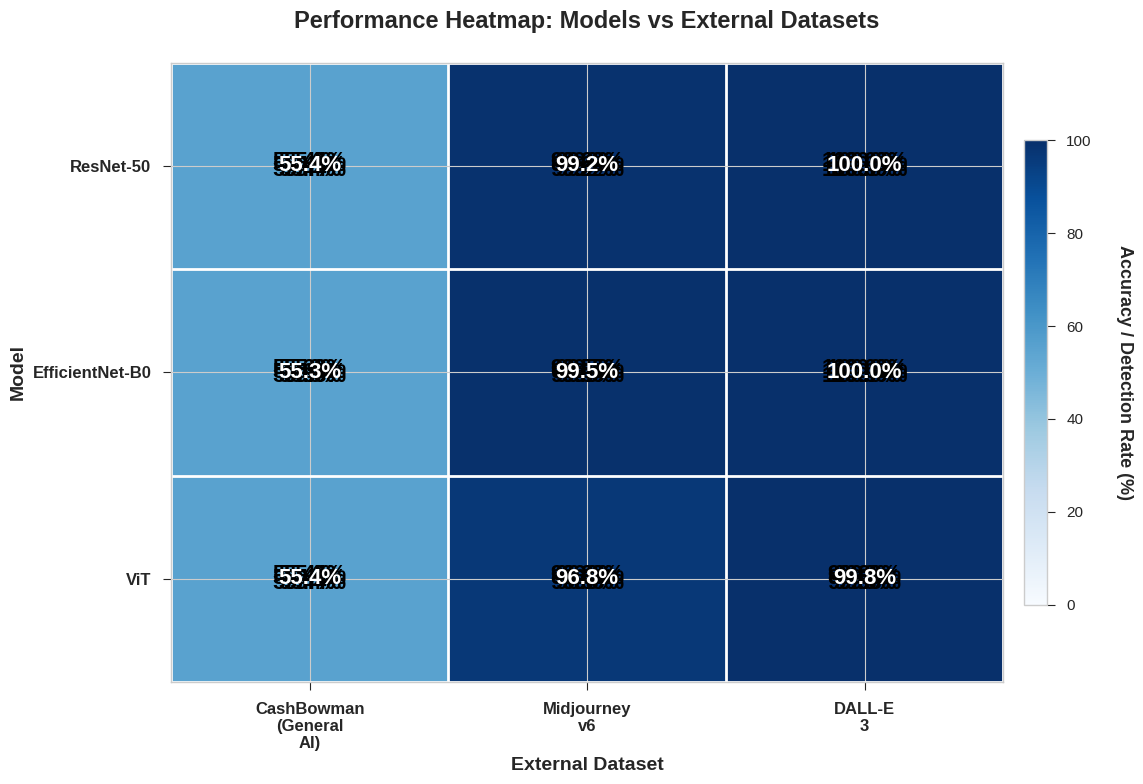

✓ Saved: external_benchmark_heatmap.png


In [34]:
# Figure 2: Heatmap - Performance Matrix
fig, ax = plt.subplots(figsize=(12, 8))

datasets = list(benchmark_results.keys())
models = ['resnet50', 'efficientnet_b0', 'vit']
model_names_display = ['ResNet-50', 'EfficientNet-B0', 'ViT']

# Prepare data for heatmap
heatmap_data = []
for model in models:
    row = [benchmark_results[dataset][model] for dataset in datasets]
    heatmap_data.append(row)

heatmap_data = np.array(heatmap_data)

# Use a professional colormap - 'Blues' for clean, modern look
# Goes from light blue (low values) to dark blue (high values)
im = ax.imshow(heatmap_data, cmap='Blues', aspect='auto', vmin=0, vmax=100)

# Set ticks and labels - NO SLANTED TEXT
ax.set_xticks(np.arange(len(datasets)))
ax.set_yticks(np.arange(len(models)))
# Use horizontal text with line breaks
dataset_labels = [d.replace(' ', '\n') for d in datasets]
ax.set_xticklabels(dataset_labels, rotation=0, ha='center', fontsize=12, fontweight='bold')
ax.set_yticklabels(model_names_display, fontsize=12, fontweight='bold')

# Add text annotations with EXCELLENT readability
# Always use white text with black outline for maximum readability on all backgrounds
for i in range(len(models)):
    for j in range(len(datasets)):
        value = heatmap_data[i, j]
        
        # Add text with a strong black outline for maximum readability
        # Draw outline first (8 directions around the text) - thicker outline
        for dx, dy in [(-0.02, -0.02), (-0.02, 0), (-0.02, 0.02), 
                       (0, -0.02), (0, 0.02), (0.02, -0.02), 
                       (0.02, 0), (0.02, 0.02)]:
            ax.text(j + dx, i + dy, f'{value:.1f}%',
                   ha="center", va="center", color='black', 
                   fontweight='bold', fontsize=16, alpha=1.0, zorder=1)
        
        # Then draw the main white text on top
        text = ax.text(j, i, f'{value:.1f}%',
                      ha="center", va="center", color='white', 
                      fontweight='bold', fontsize=16, zorder=2)

ax.set_title('Performance Heatmap: Models vs External Datasets', 
             fontsize=17, fontweight='bold', pad=25)
ax.set_xlabel('External Dataset', fontweight='bold', fontsize=14)
ax.set_ylabel('Model', fontweight='bold', fontsize=14)

# Add colorbar with better styling
cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label('Accuracy / Detection Rate (%)', rotation=270, 
               labelpad=30, fontweight='bold', fontsize=13)
cbar.ax.tick_params(labelsize=11)

# Add grid lines for better cell separation
ax.set_xticks(np.arange(len(datasets) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(models) + 1) - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)

plt.tight_layout()
plt.savefig('external_benchmark_heatmap.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()
print("✓ Saved: external_benchmark_heatmap.png")


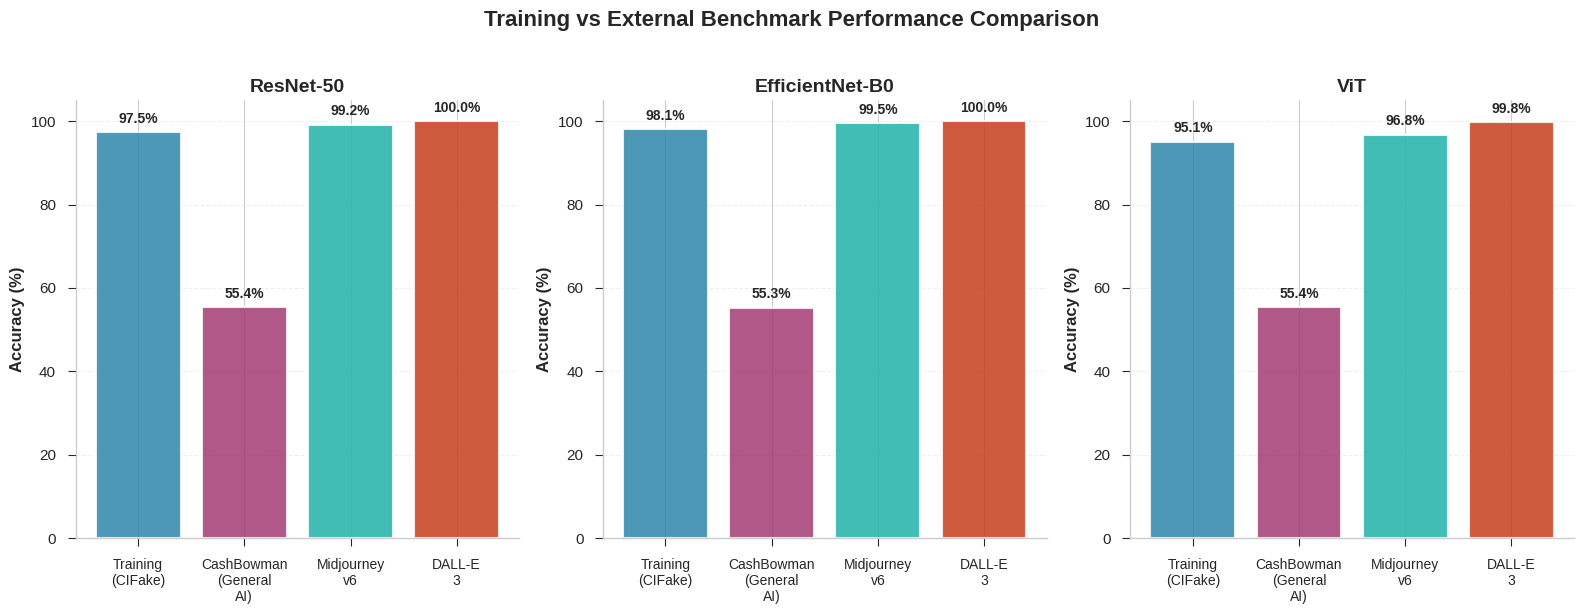

✓ Saved: training_vs_external_comparison.png


In [30]:
# Figure 3: Training vs External Benchmark Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

datasets = list(benchmark_results.keys())
model_names_display = ['ResNet-50', 'EfficientNet-B0', 'ViT']
model_keys = ['resnet50', 'efficientnet_b0', 'vit']

# Modern color palette
base_colors = ['#2E86AB', '#A23B72', '#20B2AA', '#C73E1D']  # Blue, Purple, Teal, Red

for idx, (model_key, model_display) in enumerate(zip(model_keys, model_names_display)):
    ax = axes[idx]
    
    # Training accuracy
    train_acc = training_accuracies[model_key]
    
    # External dataset accuracies
    external_accs = [benchmark_results[dataset][model_key] for dataset in datasets]
    
    # Create grouped bar chart
    x_pos = np.arange(len(datasets) + 1)  # +1 for training
    categories = ['Training\n(CIFake)'] + [d.replace(' ', '\n') for d in datasets]
    
    # Colors: training in blue, external in different colors
    colors = [base_colors[0]] + base_colors[1:4]
    
    values = [train_acc] + external_accs
    bars = ax.bar(x_pos, values, color=colors, alpha=0.85, 
                  edgecolor='white', linewidth=1.5)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1.5, 
               f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
    ax.set_title(f'{model_display}', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(categories, rotation=0, ha='center', fontsize=10)
    ax.set_ylim([0, 105])
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Removed training baseline line - the training bar itself already shows the training accuracy

plt.suptitle('Training vs External Benchmark Performance Comparison', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_vs_external_comparison.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()
print("✓ Saved: training_vs_external_comparison.png")


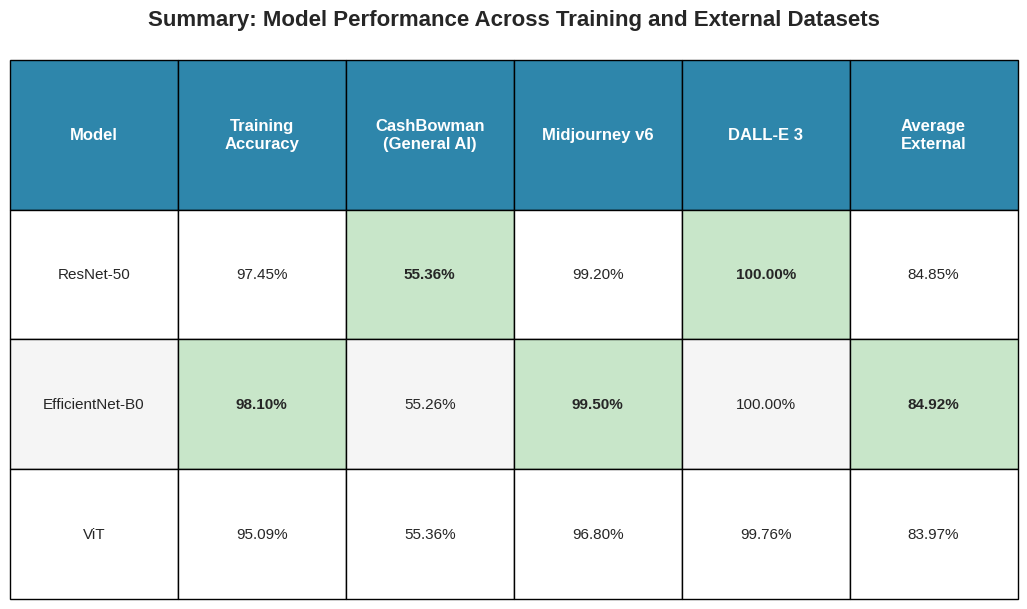

✓ Saved: benchmark_summary_table.png


In [31]:
# Figure 4: Summary Statistics Table Visualization
fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('tight')
ax.axis('off')

datasets = list(benchmark_results.keys())
model_names_display = ['ResNet-50', 'EfficientNet-B0', 'ViT']
model_keys = ['resnet50', 'efficientnet_b0', 'vit']

# Prepare table data
table_data = []
headers = ['Model', 'Training\nAccuracy', 'CashBowman\n(General AI)', 
           'Midjourney v6', 'DALL-E 3', 'Average\nExternal']

for model_key, model_display in zip(model_keys, model_names_display):
    train_acc = training_accuracies[model_key]
    cashbowman = benchmark_results['CashBowman (General AI)'][model_key]
    midjourney = benchmark_results['Midjourney v6'][model_key]
    dalle = benchmark_results['DALL-E 3'][model_key]
    avg_external = np.mean([cashbowman, midjourney, dalle])
    
    table_data.append([
        model_display,
        f'{train_acc:.2f}%',
        f'{cashbowman:.2f}%',
        f'{midjourney:.2f}%',
        f'{dalle:.2f}%',
        f'{avg_external:.2f}%'
    ])

# Create table
table = ax.table(cellText=table_data, colLabels=headers, 
                cellLoc='center', loc='center',
                bbox=[0, 0, 1, 1])

# Style the table with better colors
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.2)

# Modern header color
header_color = '#2E86AB'  # Professional blue
for i in range(len(headers)):
    table[(0, i)].set_facecolor(header_color)
    table[(0, i)].set_text_props(weight='bold', color='white')
    table[(0, i)].set_height(0.15)

# Alternate row colors with better contrast
row_colors = ['#FFFFFF', '#F5F5F5']  # White and light gray
for i in range(1, len(table_data) + 1):
    for j in range(len(headers)):
        color_idx = (i - 1) % 2
        table[(i, j)].set_facecolor(row_colors[color_idx])
        table[(i, j)].set_height(0.13)
        table[(i, j)].set_text_props(fontsize=11)

# Highlight best values in each column with subtle green
highlight_color = '#C8E6C9'  # Light green
for col_idx in range(1, len(headers)):  # Skip model name column
    values = []
    for row_idx in range(1, len(table_data) + 1):
        val_str = table_data[row_idx - 1][col_idx].replace('%', '')
        values.append(float(val_str))
    
    best_idx = np.argmax(values)
    table[(best_idx + 1, col_idx)].set_facecolor(highlight_color)
    table[(best_idx + 1, col_idx)].set_text_props(weight='bold')

plt.title('Summary: Model Performance Across Training and External Datasets', 
         fontsize=16, fontweight='bold', pad=25)
plt.savefig('benchmark_summary_table.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()
print("✓ Saved: benchmark_summary_table.png")


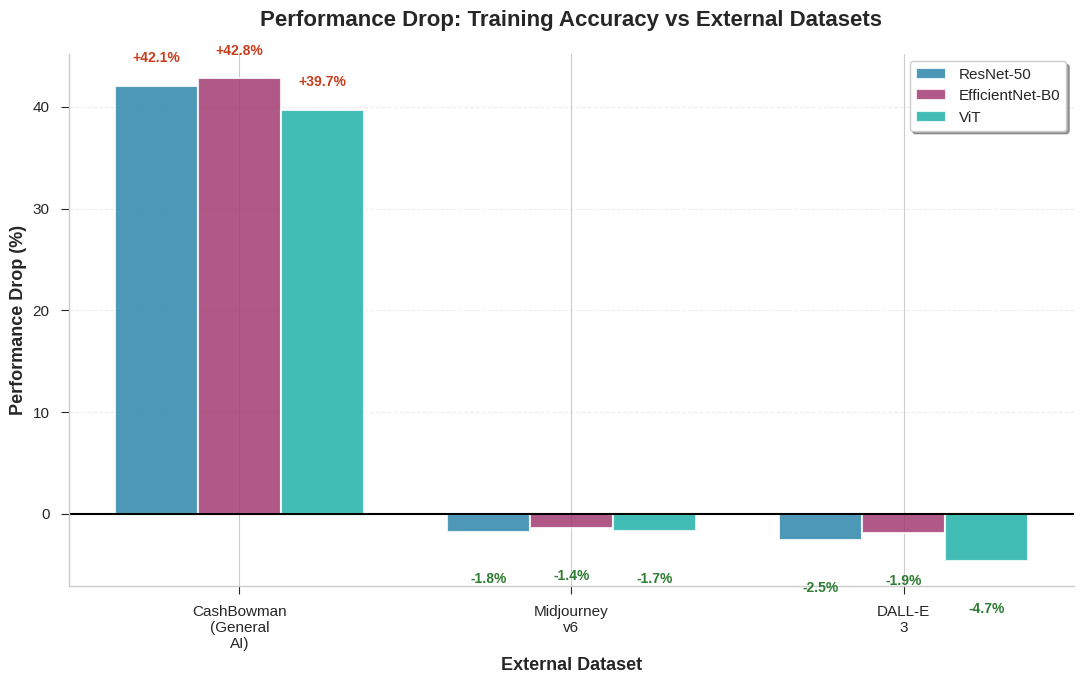

✓ Saved: performance_drop_analysis.png


In [32]:
# Figure 5: Performance Drop Analysis (Training vs External)
fig, ax = plt.subplots(figsize=(11, 7))

datasets = list(benchmark_results.keys())
model_names_display = ['ResNet-50', 'EfficientNet-B0', 'ViT']
model_keys = ['resnet50', 'efficientnet_b0', 'vit']

# Calculate performance drop for each model-dataset combination
model_names = []
dataset_names = []
drop_values = []

for model_key, model_display in zip(model_keys, model_names_display):
    train_acc = training_accuracies[model_key]
    for dataset in datasets:
        external_acc = benchmark_results[dataset][model_key]
        drop = train_acc - external_acc
        model_names.append(model_display)
        dataset_names.append(dataset)
        drop_values.append(drop)

# Create grouped bar chart
x = np.arange(len(datasets))
width = 0.25

# Modern color palette
colors = ['#2E86AB', '#A23B72', '#20B2AA']  # Blue, Purple, Teal

for i, (model_key, model_display) in enumerate(zip(model_keys, model_names_display)):
    train_acc = training_accuracies[model_key]
    drops = [train_acc - benchmark_results[dataset][model_key] for dataset in datasets]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, drops, width, label=model_display, alpha=0.85,
                  color=colors[i], edgecolor='white', linewidth=1.5)

# Customize - NO SLANTED TEXT
ax.set_xlabel('External Dataset', fontweight='bold', fontsize=13)
ax.set_ylabel('Performance Drop (%)', fontweight='bold', fontsize=13)
ax.set_title('Performance Drop: Training Accuracy vs External Datasets', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
# Fix: Use horizontal text with line breaks
dataset_labels = [d.replace(' ', '\n') for d in datasets]
ax.set_xticklabels(dataset_labels, rotation=0, ha='center', fontsize=11)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels with better positioning
for i, (model_key, model_display) in enumerate(zip(model_keys, model_names_display)):
    train_acc = training_accuracies[model_key]
    drops = [train_acc - benchmark_results[dataset][model_key] for dataset in datasets]
    offset = (i - 1) * width
    for j, drop in enumerate(drops):
        # Use darker colors for better readability
        text_color = '#C73E1D' if drop > 0 else '#2E7D32'  # Red for drop, green for gain
        label = f'{drop:+.1f}%'
        ax.text(j + offset, drop + (2 if drop >= 0 else -4), label, 
               ha='center', va='bottom' if drop >= 0 else 'top', 
               fontsize=10, fontweight='bold', color=text_color)

plt.tight_layout()
plt.savefig('performance_drop_analysis.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()
print("✓ Saved: performance_drop_analysis.png")


In [33]:
# Summary: Export all results to CSV for further analysis
import pandas as pd

datasets = list(benchmark_results.keys())
model_names_display = ['ResNet-50', 'EfficientNet-B0', 'ViT']
model_keys = ['resnet50', 'efficientnet_b0', 'vit']

# Create comprehensive results dataframe
results_list = []
for model_key, model_display in zip(model_keys, model_names_display):
    train_acc = training_accuracies[model_key]
    for dataset in datasets:
        external_acc = benchmark_results[dataset][model_key]
        results_list.append({
            'Model': model_display,
            'Dataset': dataset,
            'Accuracy (%)': external_acc,
            'Training Accuracy (%)': train_acc,
            'Performance Drop (%)': train_acc - external_acc
        })

df_results = pd.DataFrame(results_list)

# Also create a summary by model
summary_list = []
for model_key, model_display in zip(model_keys, model_names_display):
    train_acc = training_accuracies[model_key]
    external_accs = [benchmark_results[dataset][model_key] for dataset in datasets]
    avg_external = np.mean(external_accs)
    std_external = np.std(external_accs)
    
    summary_list.append({
        'Model': model_display,
        'Training Accuracy (%)': train_acc,
        'Avg External Accuracy (%)': avg_external,
        'Std External Accuracy (%)': std_external,
        'Min External Accuracy (%)': np.min(external_accs),
        'Max External Accuracy (%)': np.max(external_accs)
    })

df_summary = pd.DataFrame(summary_list)

# Save to CSV
df_results.to_csv('external_benchmark_detailed_results.csv', index=False)
df_summary.to_csv('external_benchmark_summary.csv', index=False)

print("=" * 60)
print("VISUALIZATION SUMMARY")
print("=" * 60)
print("\nGenerated Figures:")
print("  1. external_benchmark_comparison.png - Bar chart comparison")
print("  2. external_benchmark_heatmap.png - Performance heatmap")
print("  3. training_vs_external_comparison.png - Training vs external")
print("  4. benchmark_summary_table.png - Summary table")
print("  5. performance_drop_analysis.png - Performance drop analysis")
print("  6. radar_chart_performance.png - Radar chart view")
print("\nGenerated CSV Files:")
print("  1. external_benchmark_detailed_results.csv")
print("  2. external_benchmark_summary.csv")
print("\n" + "=" * 60)

# Display summary table
print("\nSummary Statistics:")
print(df_summary.to_string(index=False))


VISUALIZATION SUMMARY

Generated Figures:
  1. external_benchmark_comparison.png - Bar chart comparison
  2. external_benchmark_heatmap.png - Performance heatmap
  3. training_vs_external_comparison.png - Training vs external
  4. benchmark_summary_table.png - Summary table
  5. performance_drop_analysis.png - Performance drop analysis
  6. radar_chart_performance.png - Radar chart view

Generated CSV Files:
  1. external_benchmark_detailed_results.csv
  2. external_benchmark_summary.csv


Summary Statistics:
          Model  Training Accuracy (%)  Avg External Accuracy (%)  Std External Accuracy (%)  Min External Accuracy (%)  Max External Accuracy (%)
      ResNet-50                  97.45                  84.853333                  20.857493                      55.36                     100.00
EfficientNet-B0                  98.10                  84.920000                  20.973780                      55.26                     100.00
            ViT                  95.09      